# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [12]:
import pandas as pd
import numpy as np

data = pd.read_csv('data.csv')

data['plans_university'] = np.sign(data['plans_universitypast_failures'])
data['past_failures'] = data['plans_universitypast_failures'].abs() % 10
data = data.drop('plans_universitypast_failures', axis = 1)

display(data.head(10))

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures
0,16,4,4,1,2,5,4,4.0,1.0,2.0,5,1,1,0,1,1,1,0
1,17,4,4,1,1,5,3,4.0,1.0,2.0,5,0,1,0,1,1,1,0
2,16,1,1,2,1,4,5,5.0,2.0,4.0,5,1,0,1,1,1,1,0
3,18,1,2,2,1,3,4,4.0,2.0,4.0,4,1,1,0,1,0,-1,0
4,17,2,1,2,2,4,2,5.0,1.0,2.0,5,0,0,0,1,1,1,0
5,17,2,4,1,2,4,3,2.0,1.0,1.0,5,0,1,1,1,1,1,0
6,15,1,1,3,2,4,2,1.0,1.0,2.0,2,0,0,0,1,1,1,0
7,15,3,3,1,4,4,3,3.0,1.0,1.0,4,0,1,0,0,1,1,0
8,19,1,1,3,1,4,4,4.0,3.0,3.0,5,1,0,0,1,1,1,1
9,17,1,1,1,3,4,3,2.0,1.0,2.0,4,0,1,1,1,1,1,0


### Задача 2: пропуски в данных 
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [13]:
for column in data.columns:
    if data[column].isnull().sum() > 0:
        data.loc[data[column].isnull(), column] = data[column].mean()
print(data.isnull().sum())

age                 0
Medu                0
Fedu                0
traveltime          0
studytime           0
famrel              0
freetime            0
goout               0
Dalc                0
Walc                0
health              0
sex_M               0
address_U           0
famsize_LE3         0
Pstatus_T           0
nursery             0
plans_university    0
past_failures       0
dtype: int64


### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [14]:
def normalize(data):
    X = data.values

    mean = X.mean(axis = 0)
    std = X.std(axis = 0)

    X_normalized = (X - mean) / std

    return pd.DataFrame(X_normalized, columns = data.columns)

data_normalized = normalize(data)

display(data_normalized.head(10))

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures
0,-0.134205,1.310216,1.540715,-0.275347,0.083653,1.119748,0.780478,0.692772,-0.542692,-0.223769,1.012903,1.199937,0.660182,-0.648175,0.374963,0.495663,0.344914,-0.374305
1,-0.130277,1.310216,1.540715,-0.275347,-1.122808,1.119748,-0.171647,0.692772,-0.542692,-0.223769,1.012903,-0.833377,0.660182,-0.648175,0.374963,0.495663,0.344914,-0.374305
2,-0.134205,-1.336039,-1.188832,0.093107,-1.122808,0.072606,1.732603,1.544607,0.547811,1.340184,1.012903,1.199937,-1.514733,1.542792,0.374963,0.495663,0.344914,-0.374305
3,-0.126349,-1.336039,-0.278983,0.093107,-1.122808,-0.974536,0.780478,0.692772,0.547811,1.340184,0.320930,1.199937,0.660182,-0.648175,0.374963,-2.017502,-2.899275,-0.374305
4,-0.130277,-0.453954,-1.188832,0.093107,0.083653,0.072606,-1.123771,1.544607,-0.542692,-0.223769,1.012903,-0.833377,-1.514733,-0.648175,0.374963,0.495663,0.344914,-0.374305
5,-0.130277,-0.453954,1.540715,-0.275347,0.083653,0.072606,-0.171647,-1.010896,-0.542692,-1.005746,1.012903,-0.833377,0.660182,1.542792,0.374963,0.495663,0.344914,-0.374305
6,-0.138133,-1.336039,-1.188832,0.461561,0.083653,0.072606,-1.123771,-1.862730,-0.542692,-0.223769,-1.063015,-0.833377,-1.514733,-0.648175,0.374963,0.495663,0.344914,-0.374305
7,-0.138133,0.428131,0.630866,-0.275347,2.496576,0.072606,-0.171647,-0.159062,-0.542692,-1.005746,0.320930,-0.833377,0.660182,-0.648175,-2.666927,0.495663,0.344914,-0.374305
8,-0.122420,-1.336039,-1.188832,0.461561,-1.122808,0.072606,0.780478,0.692772,1.638314,0.558207,1.012903,1.199937,-1.514733,-0.648175,0.374963,0.495663,0.344914,1.312667
9,-0.130277,-1.336039,-1.188832,-0.275347,1.290114,0.072606,-0.171647,-1.010896,-0.542692,-0.223769,0.320930,-0.833377,0.660182,1.542792,0.374963,0.495663,0.344914,-0.374305


### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

scores = pd.read_csv('scores.csv', header = None).squeeze()

model = LinearRegression()

scores_cv = cross_val_score(model, data_normalized, scores, cv = 4)

print(scores_cv)

[0.21559119 0.25926843 0.14207912 0.232442  ]


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [16]:
attendance = pd.read_csv('attendance.csv', sep=';')
support = pd.read_csv('school_support.txt', header = None)

data['attendance'] = attendance.notnull().sum(axis = 1)
data['support'] = 0
data.loc[support[0], 'support'] = 1

data_normalized_new = normalize(data)

display(data.head(10))
display(data_normalized_new.head(10))

scores_cv_new = cross_val_score(model, data_normalized_new, scores, cv = 4)
print("How scores changed:", scores_cv_new - scores_cv)
print("Average difference:", scores_cv_new.mean() - scores_cv.mean())

,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures,attendance,support
0,16,4,4,1,2,5,4,4.0,1.0,2.0,5,1,1,0,1,1,1,0,26,0
1,17,4,4,1,1,5,3,4.0,1.0,2.0,5,0,1,0,1,1,1,0,30,0
2,16,1,1,2,1,4,5,5.0,2.0,4.0,5,1,0,1,1,1,1,0,32,0
3,18,1,2,2,1,3,4,4.0,2.0,4.0,4,1,1,0,1,0,-1,0,22,0
4,17,2,1,2,2,4,2,5.0,1.0,2.0,5,0,0,0,1,1,1,0,32,0
5,17,2,4,1,2,4,3,2.0,1.0,1.0,5,0,1,1,1,1,1,0,24,0
6,15,1,1,3,2,4,2,1.0,1.0,2.0,2,0,0,0,1,1,1,0,32,0
7,15,3,3,1,4,4,3,3.0,1.0,1.0,4,0,1,0,0,1,1,0,22,1
8,19,1,1,3,1,4,4,4.0,3.0,3.0,5,1,0,0,1,1,1,1,28,0
9,17,1,1,1,3,4,3,2.0,1.0,2.0,4,0,1,1,1,1,1,0,22,0


,age,Medu,Fedu,traveltime,studytime,famrel,freetime,goout,Dalc,Walc,health,sex_M,address_U,famsize_LE3,Pstatus_T,nursery,plans_university,past_failures,attendance,support
0,-0.134205,1.310216,1.540715,-0.275347,0.083653,1.119748,0.780478,0.692772,-0.542692,-0.223769,1.012903,1.199937,0.660182,-0.648175,0.374963,0.495663,0.344914,-0.374305,-0.504730,-0.342110
1,-0.130277,1.310216,1.540715,-0.275347,-1.122808,1.119748,-0.171647,0.692772,-0.542692,-0.223769,1.012903,-0.833377,0.660182,-0.648175,0.374963,0.495663,0.344914,-0.374305,0.357863,-0.342110
2,-0.134205,-1.336039,-1.188832,0.093107,-1.122808,0.072606,1.732603,1.544607,0.547811,1.340184,1.012903,1.199937,-1.514733,1.542792,0.374963,0.495663,0.344914,-0.374305,0.789159,-0.342110
3,-0.126349,-1.336039,-0.278983,0.093107,-1.122808,-0.974536,0.780478,0.692772,0.547811,1.340184,0.320930,1.199937,0.660182,-0.648175,0.374963,-2.017502,-2.899275,-0.374305,-1.367323,-0.342110
4,-0.130277,-0.453954,-1.188832,0.093107,0.083653,0.072606,-1.123771,1.544607,-0.542692,-0.223769,1.012903,-0.833377,-1.514733,-0.648175,0.374963,0.495663,0.344914,-0.374305,0.789159,-0.342110
5,-0.130277,-0.453954,1.540715,-0.275347,0.083653,0.072606,-0.171647,-1.010896,-0.542692,-1.005746,1.012903,-0.833377,0.660182,1.542792,0.374963,0.495663,0.344914,-0.374305,-0.936026,-0.342110
6,-0.138133,-1.336039,-1.188832,0.461561,0.083653,0.072606,-1.123771,-1.862730,-0.542692,-0.223769,-1.063015,-0.833377,-1.514733,-0.648175,0.374963,0.495663,0.344914,-0.374305,0.789159,-0.342110
7,-0.138133,0.428131,0.630866,-0.275347,2.496576,0.072606,-0.171647,-0.159062,-0.542692,-1.005746,0.320930,-0.833377,0.660182,-0.648175,-2.666927,0.495663,0.344914,-0.374305,-1.367323,2.923032
8,-0.122420,-1.336039,-1.188832,0.461561,-1.122808,0.072606,0.780478,0.692772,1.638314,0.558207,1.012903,1.199937,-1.514733,-0.648175,0.374963,0.495663,0.344914,1.312667,-0.073433,-0.342110
9,-0.130277,-1.336039,-1.188832,-0.275347,1.290114,0.072606,-0.171647,-1.010896,-0.542692,-0.223769,0.320930,-0.833377,0.660182,1.542792,0.374963,0.495663,0.344914,-0.374305,-1.367323,-0.342110


How scores changed: [ 0.03144998  0.01875534 -0.03278217  0.00068455]
Average difference: 0.004526924510141139


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

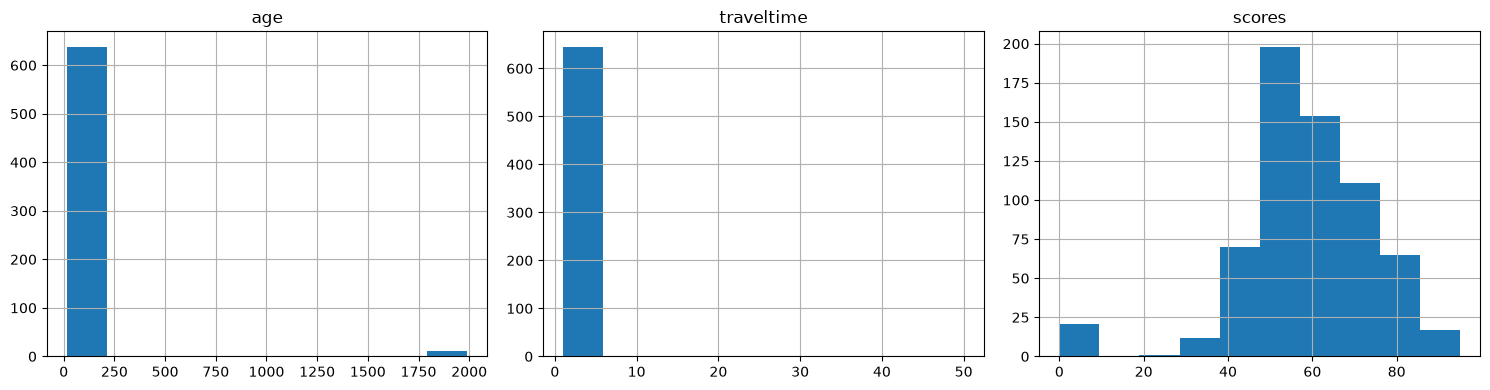

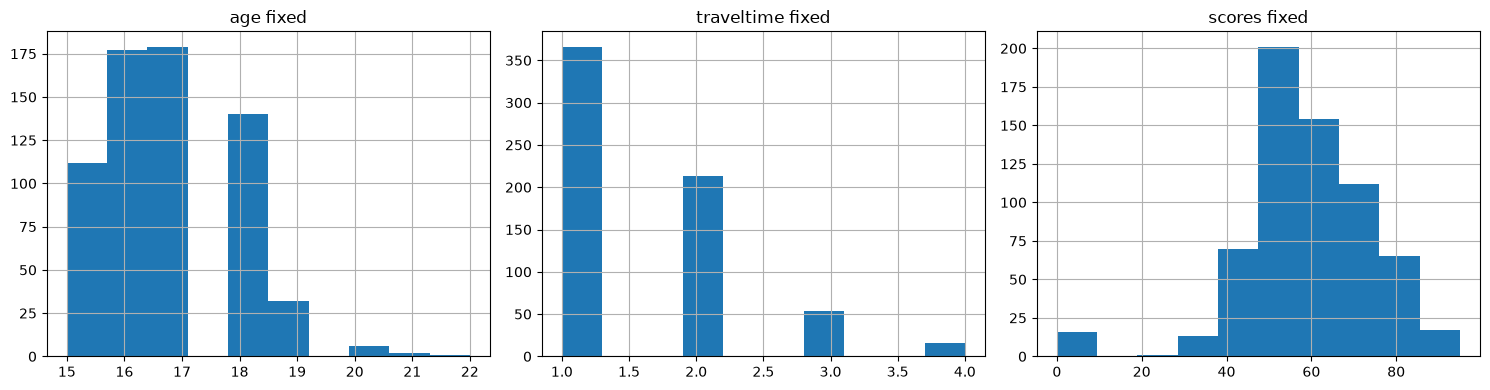

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize = (15, 4))

data["age"].hist(ax = axes[0])
axes[0].set_title("age")

data["traveltime"].hist(ax = axes[1])
axes[1].set_title("traveltime")

scores.hist(ax = axes[2])
axes[2].set_title("scores")

plt.tight_layout()
plt.show()

data_fixed = data.copy()
scores_fixed = scores.copy()

data_fixed.loc[data_fixed["age"] > 100, "age"] = 2006 - data_fixed.loc[data_fixed["age"] > 100, "age"]
data_fixed["traveltime"] = data["traveltime"].apply(
    lambda x: x if x in [1, 2, 3, 4]
    else 1 if x < 15
    else 2 if x < 30
    else 3 if x <= 60
    else 4
)
scores_fixed = scores_fixed.apply(
    lambda x: x * 100 if 0 < x < 1 else x
)
    
fig1, axes1 = plt.subplots(1, 3, figsize = (15, 4))

data_fixed["age"].hist(ax = axes1[0])
axes1[0].set_title("age fixed")

data_fixed["traveltime"].hist(ax = axes1[1])
axes1[1].set_title("traveltime fixed")

scores_fixed.hist(ax = axes1[2])
axes1[2].set_title("scores fixed")

plt.tight_layout()
plt.show()

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных. 

In [ ]:
# Your code here
# ...